In [ ]:
from IPython.display import Image, display
from matplotlib import pyplot as plt
from pathlib import Path
import folium
from folium.plugins import MarkerCluster
import numpy as np
import yaml
import os

import cv2
import torch
import pytorch_lightning as pl
from torch.utils.data import Dataset, DataLoader, random_split

from utility import latlon_to_yaw, euler_from_quaternion, transform_2d_points, resizecrop_matrix, crop_matrix, cls2one_hot
from config import GlobalConfig

config = GlobalConfig()
root_dir = Path(config.root_dir)

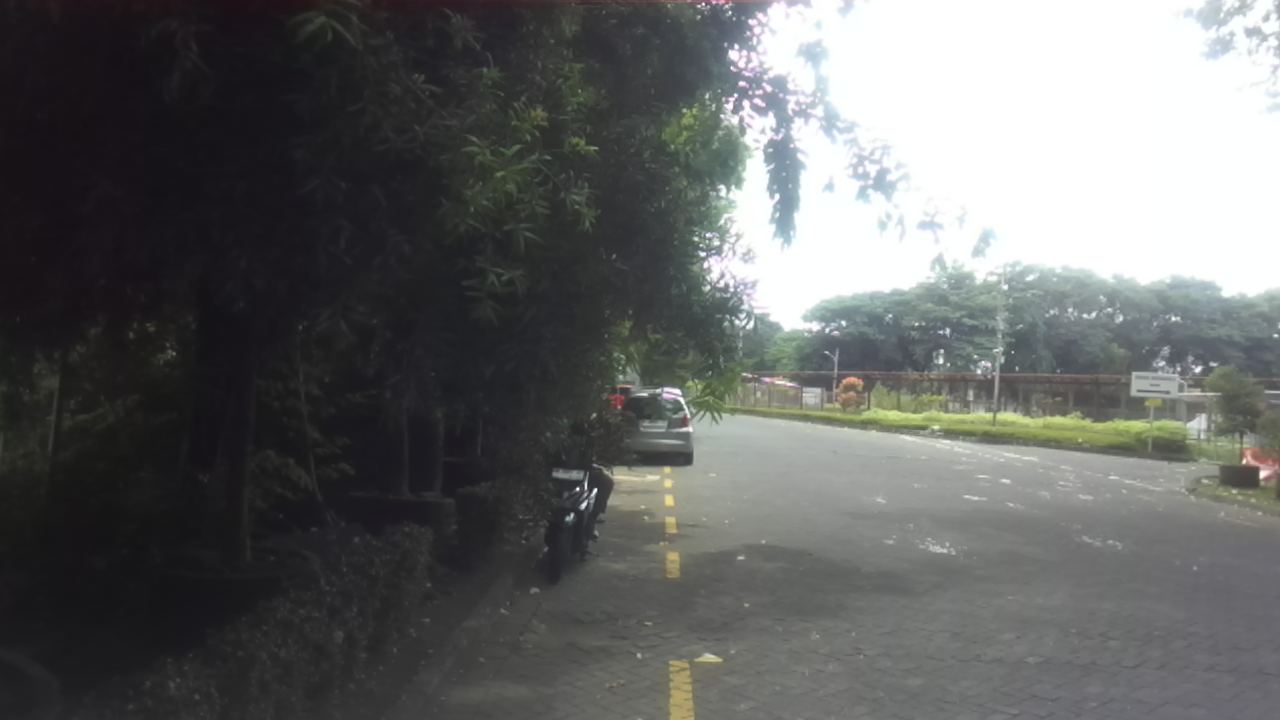

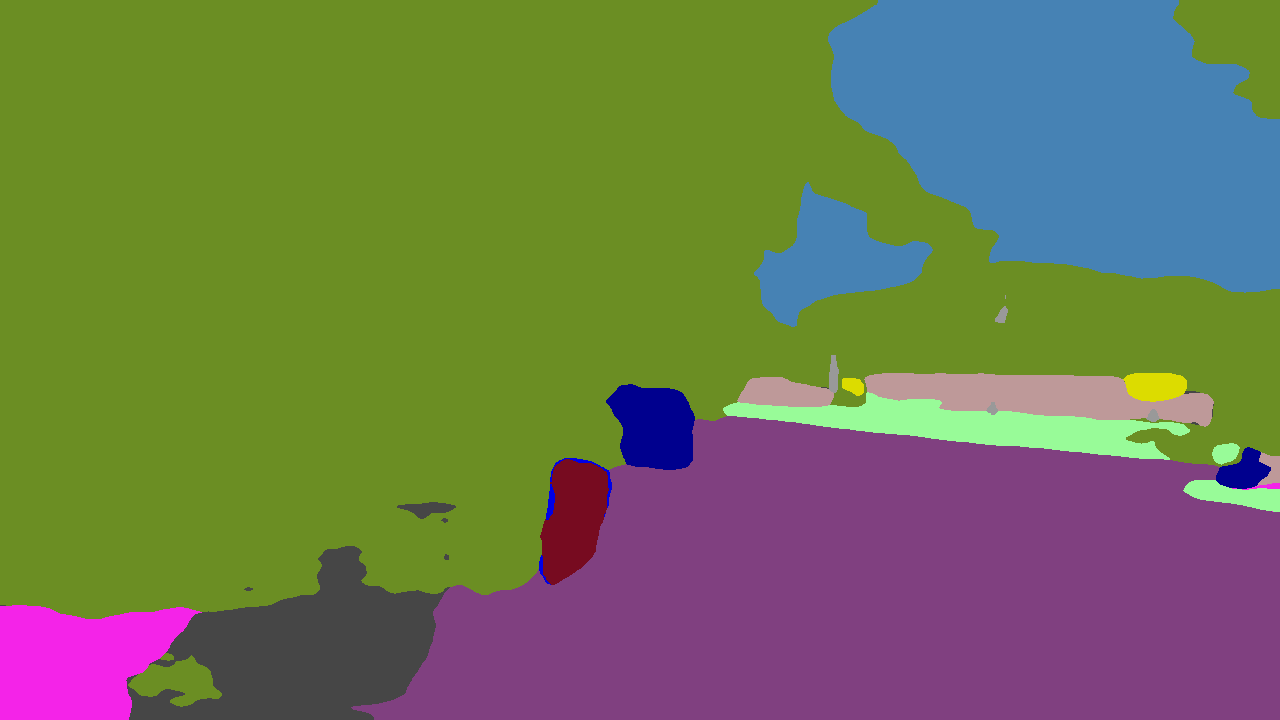

In [6]:
dir_meta = root_dir / "meta"
dir_rgb_front = root_dir / "camera" / "rgb"
dir_rgb_seg = root_dir / "camera" / "seg" / "img"
dir_depth_front = root_dir / "camera" / "depth" / "cld2"
dir_histo = root_dir / "camera" / "histogram"
dir_optflow = root_dir / "camera" / "optical_flow"

files = os.listdir(dir_meta)
files.sort()
files = [os.path.splitext(filename)[0] for filename in files] # remove extension string
len_files = len(files)

display(Image(filename=f'{dir_rgb_front}/{files[5]}.png'))
display(Image(filename=f'{dir_rgb_seg}/{files[5]}.png'))

Visualize the global position from GNSS

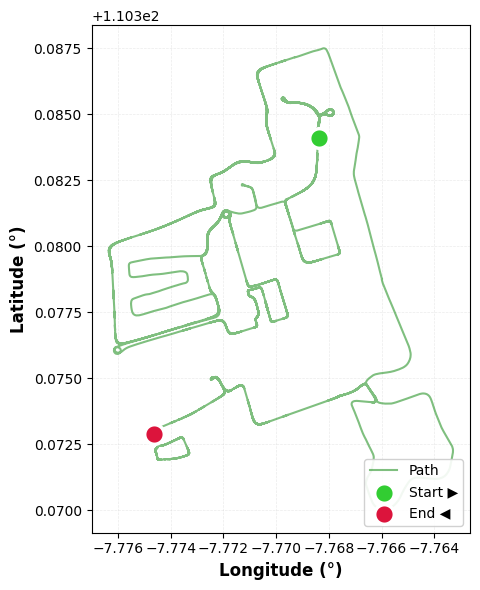

In [12]:
lats = []
lons = []

for file in files:
    with open(f'{dir_meta}/{file}.yml', 'r') as curr_metafile:
        current_meta = yaml.safe_load(curr_metafile)
        lat = current_meta["global_position_latlon"][0]
        lon = current_meta["global_position_latlon"][1]
        lats.append(lat)
        lons.append(lon)

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(lats, lons, 'g-', linewidth=1.5, label='Path', alpha=0.5)
ax.scatter(lats[0], lons[0], c='limegreen', s=200, label='Start ▶', zorder=6, edgecolors='white', linewidth=2.5)
ax.scatter(lats[-1], lons[-1], c='crimson', s=200, label='End ◀', zorder=6, edgecolors='white', linewidth=2.5)
ax.set_xlabel('Longitude (°)', fontsize=12, fontweight='bold')
ax.set_ylabel('Latitude (°)', fontsize=12, fontweight='bold')
ax.legend(loc='lower right', fontsize=10, framealpha=0.9)
ax.grid(True, alpha=0.25, linestyle='--', linewidth=0.5)
ax.set_aspect('equal')
plt.tight_layout()
plt.show()

map_location = [-7.770255, 110.376824]
m = folium.Map(location=map_location, zoom_start=16, tiles="cartodb positron")

coordinates = list(zip(lats, lons))
folium.PolyLine(
    locations=coordinates,
    color='#3388FF',
    weight=4,
    opacity=0.7,
    tooltip=f'Total distance: {len(lats)} frames'
).add_to(m)
m